# Poisson NMF of Feedforward Inputs (`compute-nmfs`)

Raw feedforward spike trains (1 500 mitral cells) are factorised with
Non-negative Matrix Factorization using the KL divergence (β=1, Poisson noise model).
No pre-smoothing — NMF is fit directly on binary spike counts.

Reconstruction: `activations @ components`.

Sections:
1. **Spike comparison** — teacher rasters vs Bernoulli-sampled NMF reconstructions.
2. **Reconstruction R²** — global R² and per-neuron R² distribution.
3. **Basis vectors** — heatmap of the NMF component matrix.
4. **Activation traces** — timeseries of the top components.

In [ ]:
import numpy as np
import zarr
import matplotlib.pyplot as plt

from connectome_snns.utils.reproducibility import load_experiment_config
from connectome_snns.visualization import use_project_style, FEEDFORWARD_COLOR
from connectome_snns.visualization.neuronal_dynamics import plot_spike_trains
from connectome_snns.analysis import r_squared

use_project_style()

In [ ]:
results_dir = load_experiment_config("experiment.toml")["output_dir"]

# ------------------------------------------------------------------
# Load NMF outputs
# ------------------------------------------------------------------
nmf_zarr = zarr.open_group(results_dir / "results" / "nmf_inputs.zarr", mode="r")
activations = nmf_zarr["activations"][:]  # (n_batches, n_timesteps, rank)
components = nmf_zarr["components"][:]  # (rank, n_ff)

rank = int(nmf_zarr.attrs["rank"])
beta = float(nmf_zarr.attrs["beta"])
dt = float(nmf_zarr.attrs["dt"])
r2_stored = float(nmf_zarr.attrs["reconstruction_r2"])

n_batches, n_timesteps, _ = activations.shape
n_ff = components.shape[1]
hz_scale = 1000.0 / dt

print(f"Activations : {activations.shape}")
print(f"Components  : {components.shape}")
print(f"rank={rank}  |  beta={beta}  |  dt={dt} ms")
print(f"Stored R²   : {r2_stored:.4f}  (Frobenius on raw spikes)")

# ------------------------------------------------------------------
# Load raw spikes
# ------------------------------------------------------------------
spike_zarr = zarr.open_group(results_dir / "inputs" / "spike_data.zarr", mode="r")
input_spikes = spike_zarr["input_spikes"][:]  # (n_batches, n_timesteps, n_ff)

# Full reconstruction (same scale as NMF was trained on — raw spikes)
reconstruction = activations @ components  # (n_batches, n_timesteps, n_ff)

print(f"\nRaw spikes    : {input_spikes.shape}")
print(f"Reconstruction: {reconstruction.shape}")
print(f"Recon range   : [{reconstruction.min():.4f}, {reconstruction.max():.4f}]")

## Spike Comparison: Teacher vs NMF

Raw teacher spike trains (top of each pair) alongside Bernoulli-sampled spikes
from the NMF reconstruction (bottom of each pair).

The NMF reconstruction `activations @ components` gives a probability per
timestep per neuron — we sample Bernoulli spikes from these for comparison.

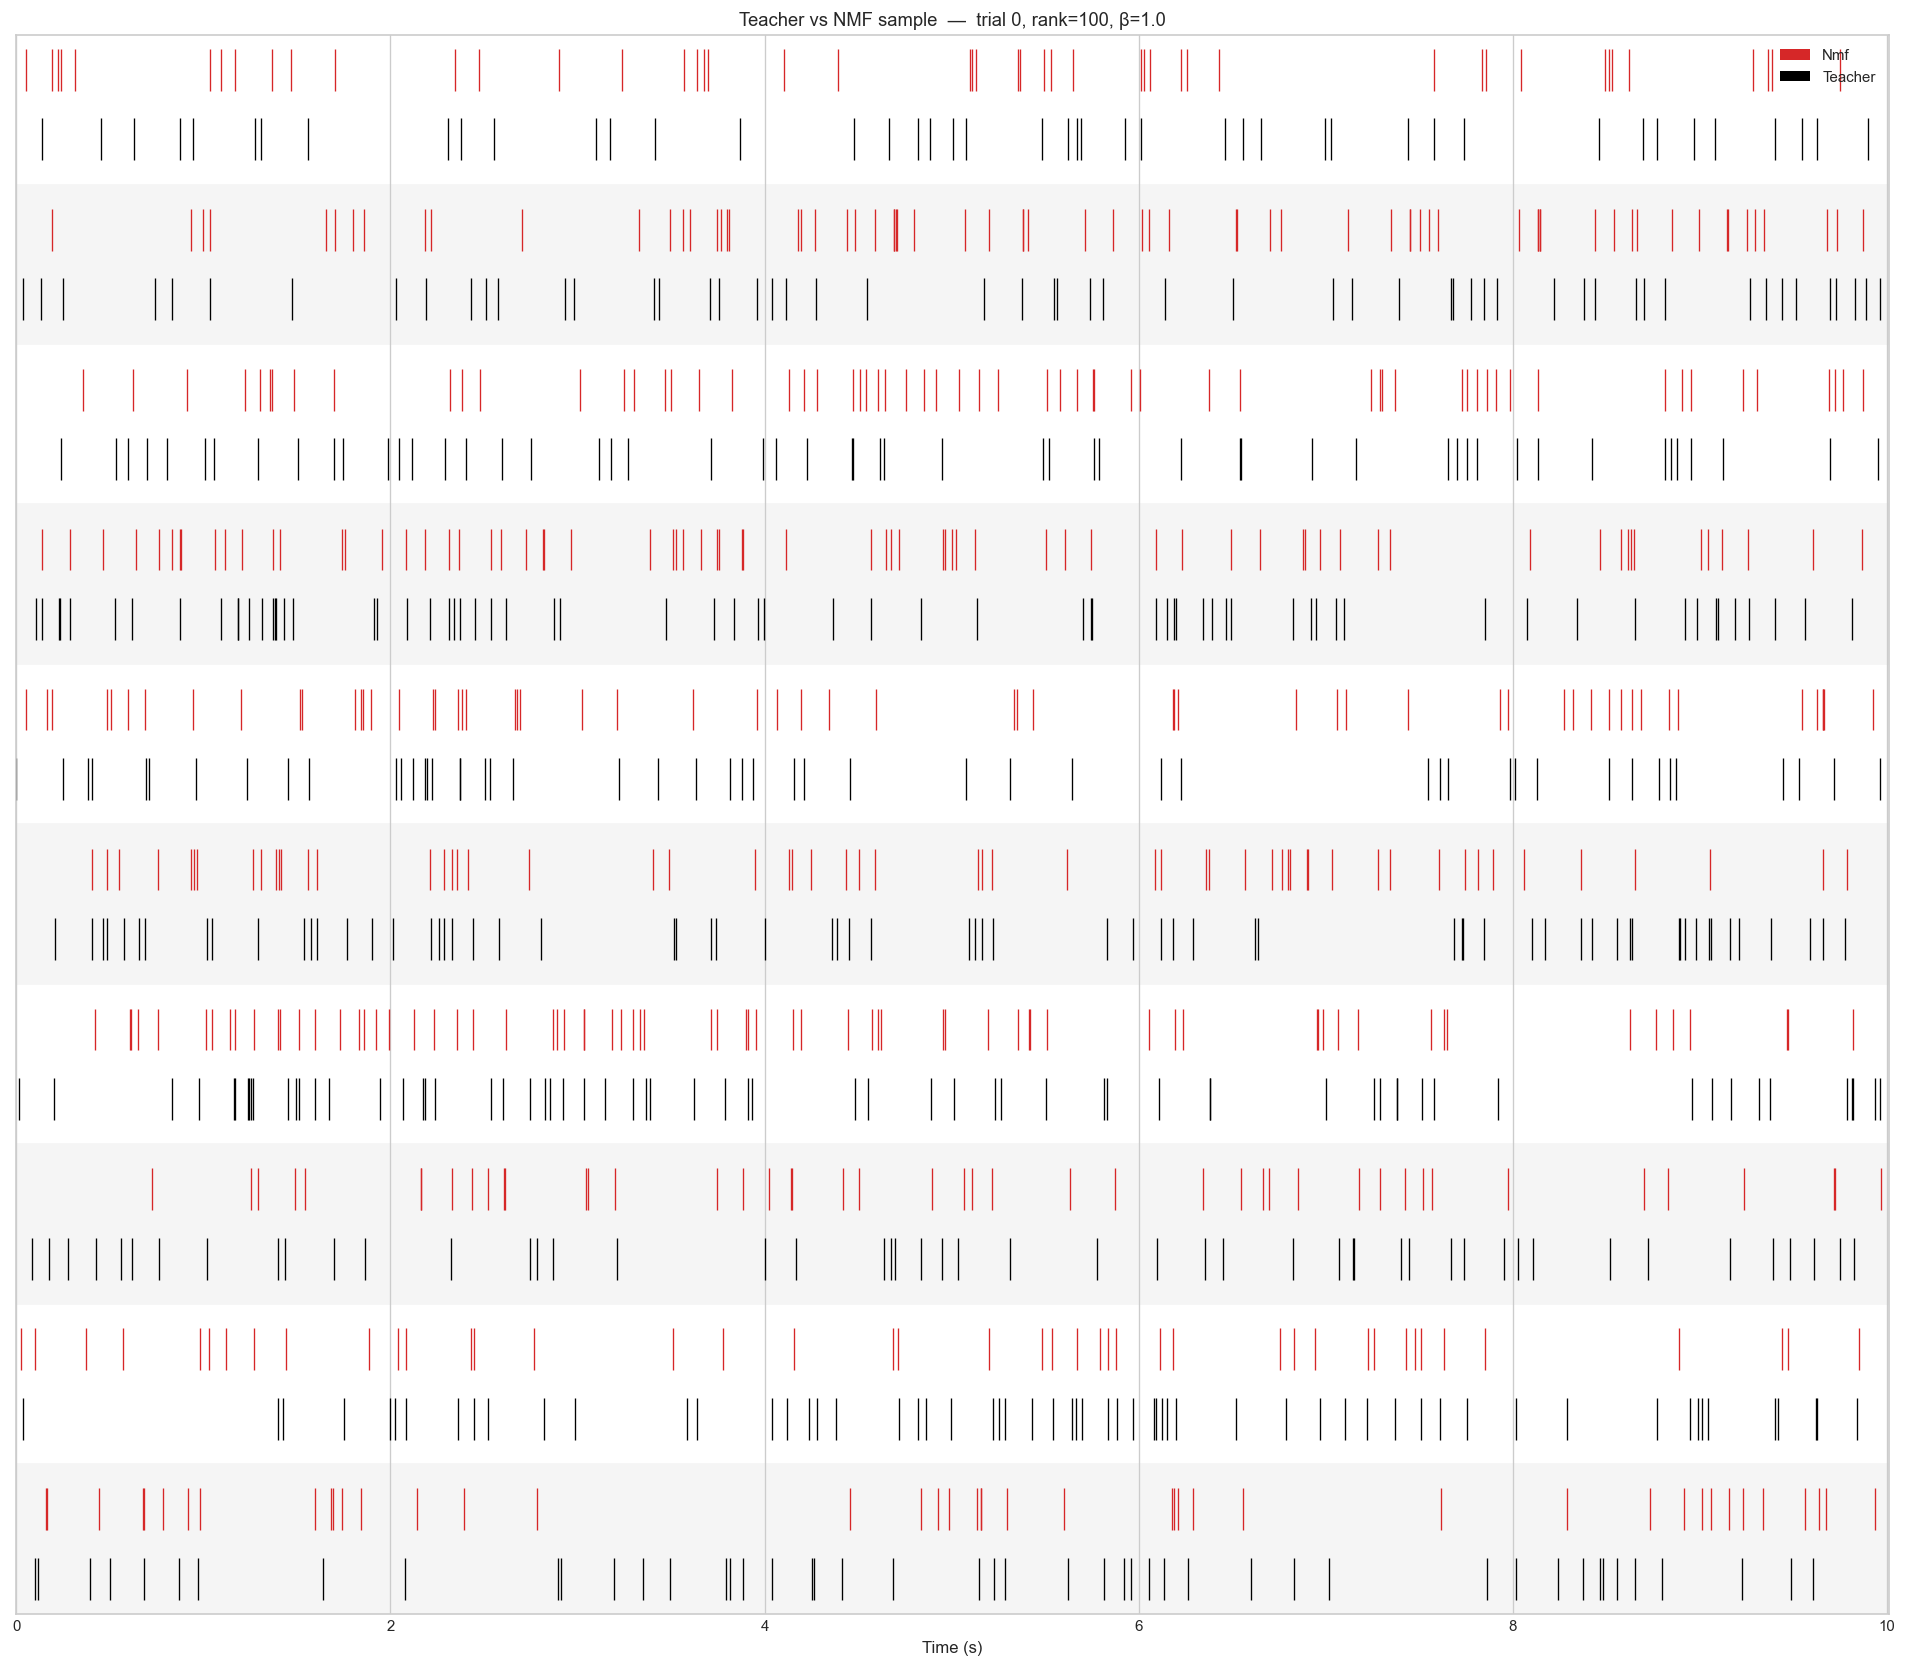

In [21]:
rng = np.random.RandomState(42)
n_example = 10
example_nids = np.sort(rng.choice(n_ff, n_example, replace=False))
example_batch = 0

# shapes: (n_timesteps, n_example)
teacher = input_spikes[example_batch][:, example_nids].astype(np.int32)
recon_probs = np.clip(reconstruction[example_batch][:, example_nids], 0, 1)
recon_sampled = rng.binomial(1, recon_probs).astype(np.int32)

# Interleave pairs: [teacher_0, recon_0, teacher_1, recon_1, ...]
n_neurons_comb = 2 * n_example
combined = np.zeros((n_timesteps, n_neurons_comb), dtype=np.int32)
combined[:, 0::2] = teacher
combined[:, 1::2] = recon_sampled

# Cell type index per interleaved neuron: 0=teacher (even), 1=NMF (odd)
cell_type_indices = np.tile([0, 1], n_example)
cell_type_names = ["Teacher", "NMF"]
cell_type_colors = {0: "black", 1: "C3"}

combined_batched = combined[np.newaxis]  # (1, n_timesteps, 2*n_example)

plot_spike_trains(
    combined_batched,
    dt=dt,
    cell_type_indices=cell_type_indices,
    cell_type_names=cell_type_names,
    cell_type_colors=cell_type_colors,
    n_neurons_plot=n_neurons_comb,
    n_compared=2,
    random_seed=None,  # preserve interleaved order — no shuffling
    title=(f"Teacher vs NMF sample  —  trial {example_batch}, rank={rank}, β={beta}"),
    figsize=(16, max(4, 0.7 * n_neurons_comb)),
)
plt.show()

## Firing Rate Comparison

Per-neuron mean firing rate (Hz) for trial 0: teacher vs NMF reconstruction.
Each point is one neuron.

In [ ]:
duration_s = n_timesteps * dt / 1000.0

# First trial only — (n_ff,)
teacher_rates = input_spikes[0].sum(axis=0) / duration_s  # Hz
recon_rates = reconstruction[0].sum(axis=0) / duration_s  # Hz

r2 = r_squared(teacher_rates, recon_rates)
print(f"R² (trial 0): {r2:.4f}")

mx = max(teacher_rates.max(), recon_rates.max()) * 1.05

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    teacher_rates,
    recon_rates,
    s=4,
    alpha=0.3,
    color=FEEDFORWARD_COLOR,
    edgecolors="none",
)
ax.plot([0, mx], [0, mx], "k--", lw=0.8, alpha=0.5)
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r2:.3f}$",
    transform=ax.transAxes,
    fontsize=12,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)
ax.set_xlabel("Teacher firing rate (Hz)")
ax.set_ylabel("NMF reconstruction (Hz)")
ax.set_title(
    f"Per-Neuron Firing Rates — trial 0  (rank={rank}, β={beta})", fontweight="bold"
)
ax.set_xlim(0, mx)
ax.set_ylim(0, mx)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()